In [1]:
# Imports
import numpy as np
import pandas as pd
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

# Leitura do Dataset
students_df = pd.read_csv("predict_students_dropout_and_academic_success.csv", sep = ";")
students_df.columns = students_df.columns.str.strip()

---

<p style="text-align: justify; font-size: 1.15em;">
A importação das bibliotecas <code>Seaborn</code>, <code>PlotyExpress</code> e <code>MatPlotLib</code> servem fundamentalmente para a plotagem gráfica da <strong>Matriz de Correlação</strong> e dos Gráficos relacionados a <strong>Análise de Principais Componentes (PCA)</strong> que foi feita nesse etapa da pesquisa. Já a biblioteca <code>Sklearn</code> e as bibliotecas <code>Numpy</code> e <code>Pandas</code> fornece diferentesm ferramentas para manipulação da base de dados e colunas, na etapa de Pré-Processamento realizada, fez-se uma <strong>normalização dos dados do tipo MinMax</strong> para a aplicação da técnica de redução de atributos da base de dados com PCA, como fundamentado no livro base norteador da disciplina.
</p>

---

In [ ]:
# Técnica de Transformação de Dados Categóricos para Numéricos da Variável Alvo
students_df['Target'] = students_df['Target'].map({"Dropout": 0, "Enrolled": 1, "Graduated": 2})

<p style="text-align: justify; font-size: 1.15em;">
A transformação dos rótulos categóricos do atributo <code>Target</code> se faz necessária visto que a manipulação da base de dados para verificação da correlação entre pares de variáveis é feita com dados numéricos. <strong>A matriz de correlação</strong> é vista abaixo e apresenta a variância normalizada entre pares de variáveis. Dessa forma, é possível verificar a <strong>correlação positiva ou negativa</strong> entre diferentes colunas no intervalo de [-1,1], além de um sinal de alerta para investigação em etapas futuras, como na Análise Descritiva. A correlação é calculada pela fórmula descrita abaixo: 
</p>

$$r = \frac{\sum (X - \bar{X})(Y - \bar{Y})}{\sqrt{\sum (X - \bar{X})^2 \sum (Y - \bar{Y})^2}}$$

<p style="text-align: justify; font-size: 1.15em;">
Onde os componentes da equação representam:
<br>• <code>r</code>: Coeficiente de correlação linear de Pearson entre as variáveis <em>X</em> e <em>Y</em>;
<br>• <code>X</code> e <code>Y</code>: Os valores observados de cada instância para os dois atributos analisados;
<br>• <code>X̄</code> (X barra) e <code>Ȳ</code> (Y barra): As médias aritméticas amostrais das respectivas variáveis <em>X</em> e <em>Y</em>;
<br>• <code>Σ</code> (Sigma): O somatório dos valores computados ao longo de todas as instâncias da base de dados.
</p>

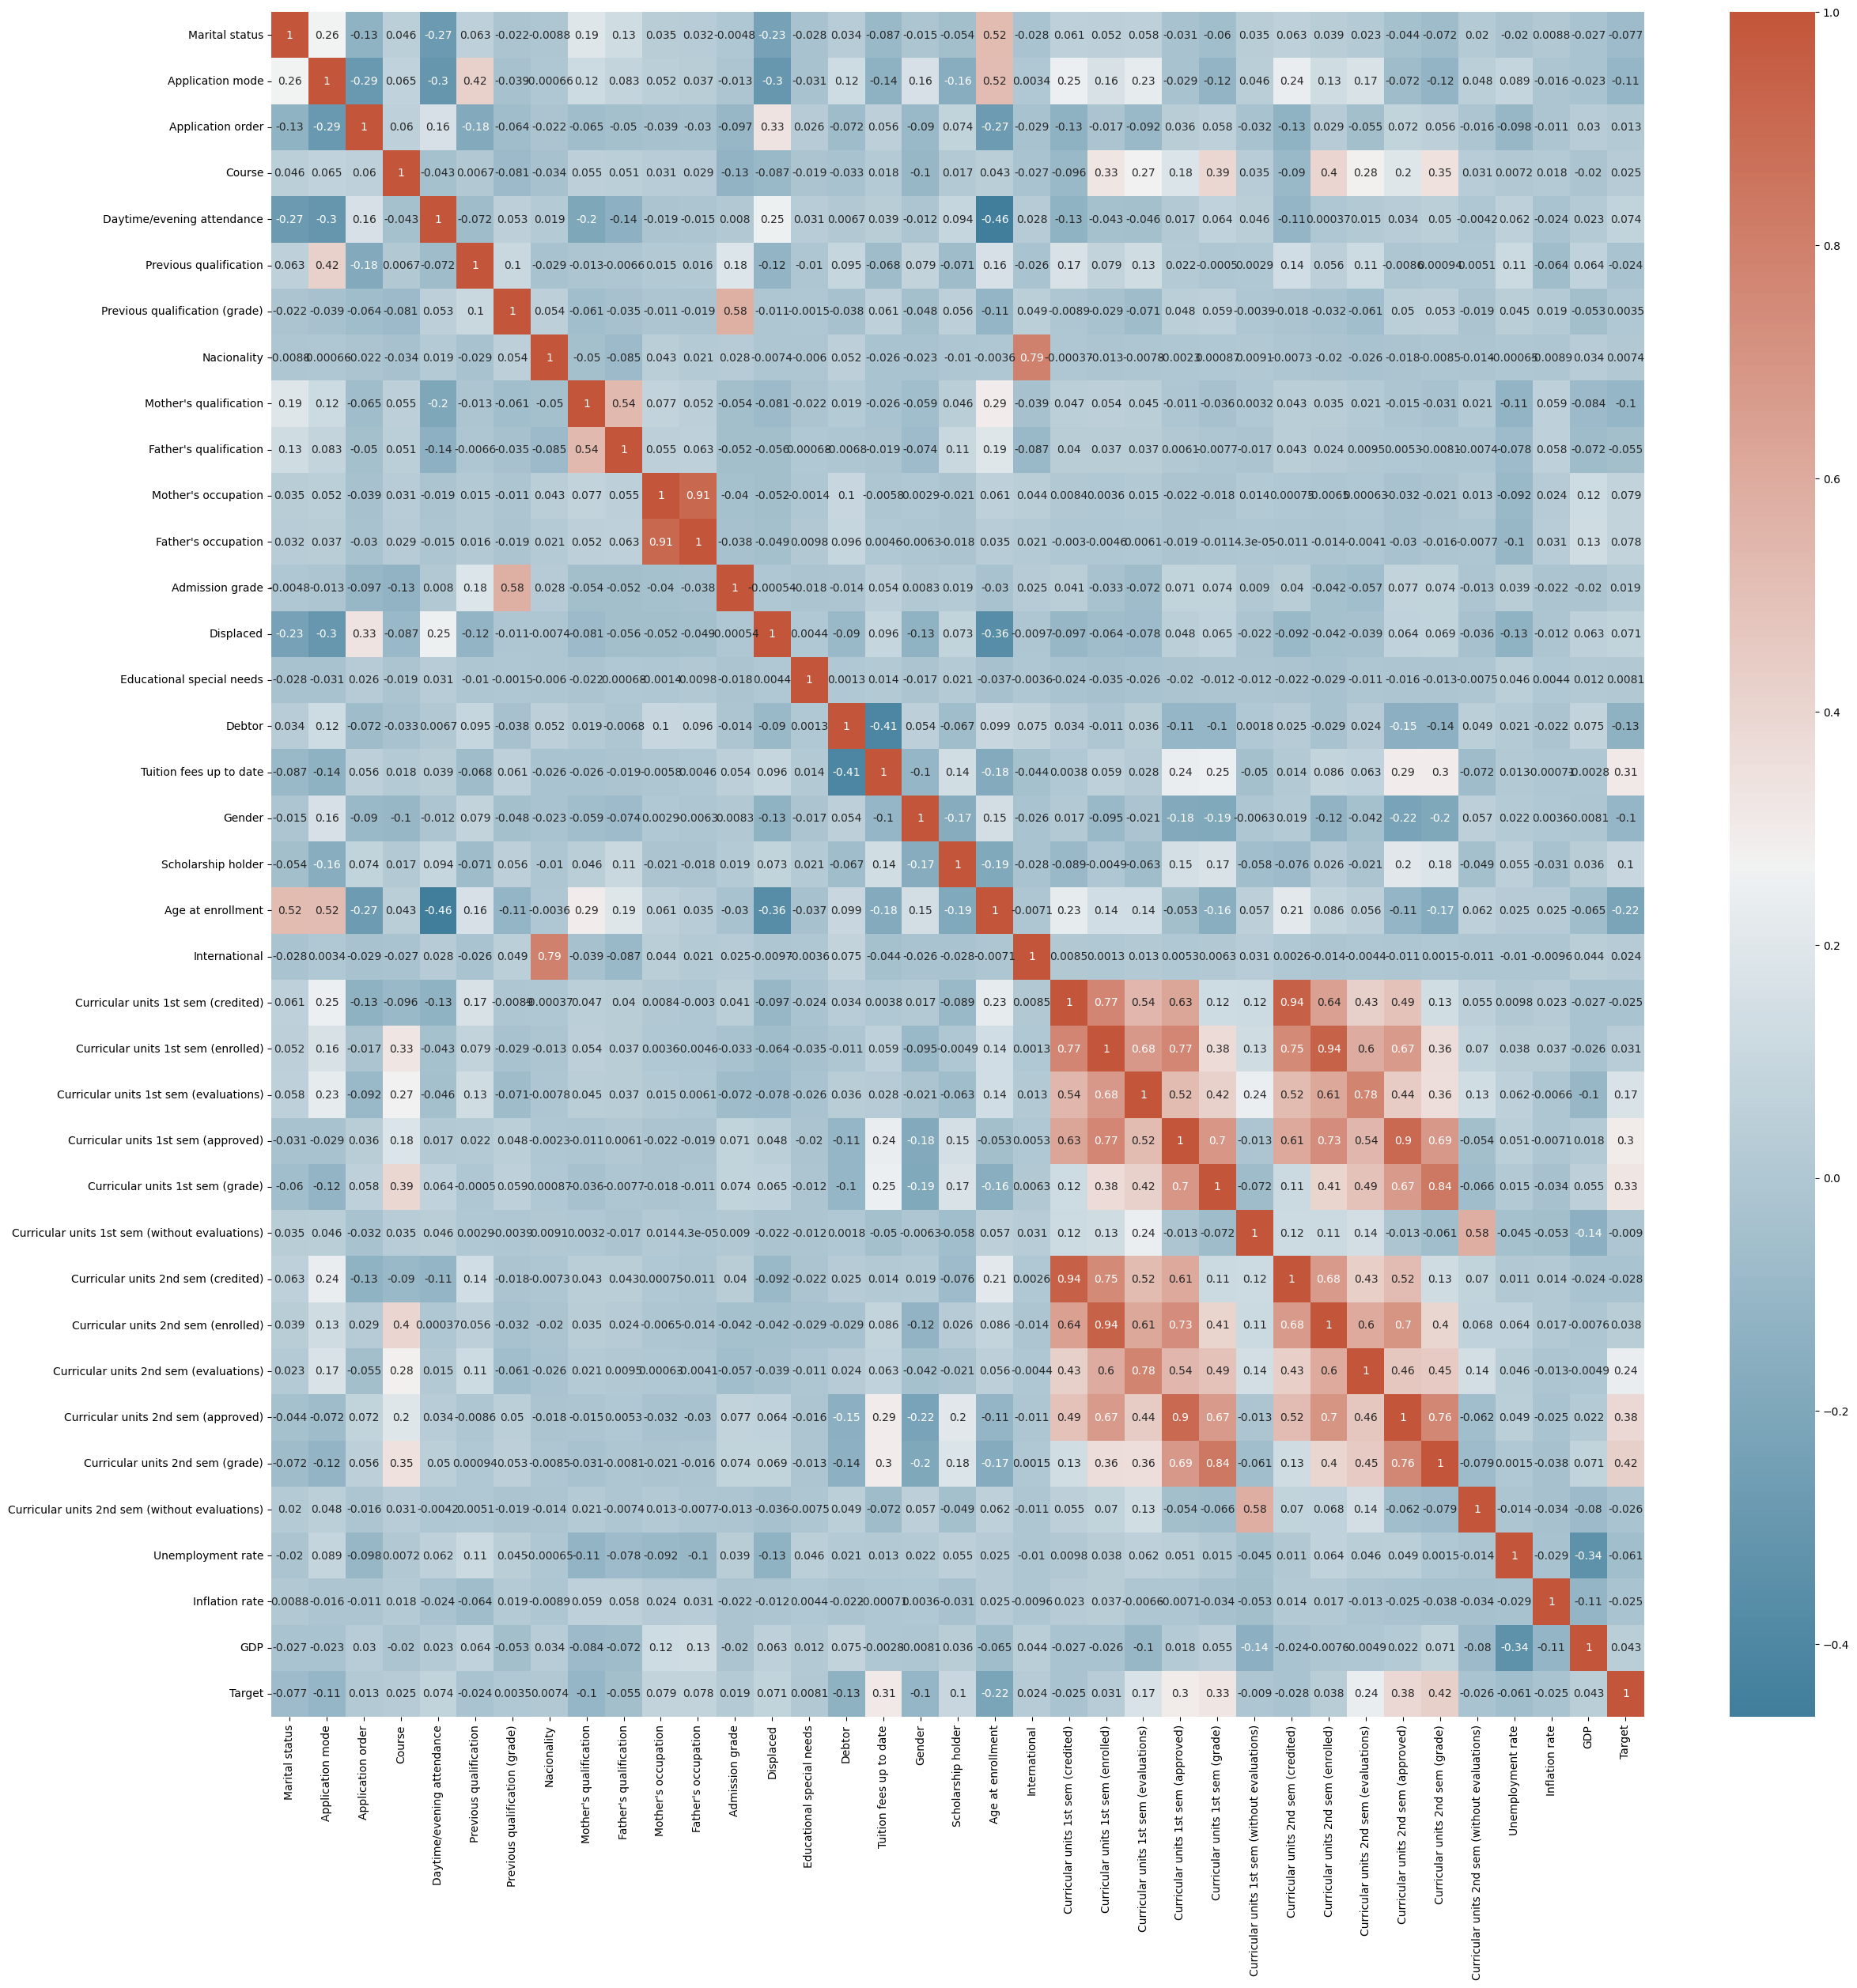

In [9]:
# Matriz de Correlação
correlation_matrix = students_df.corr()

cmap = sns.diverging_palette(230, 20, as_cmap=True)
plt.figure(figsize=(28,28))
sns.heatmap(correlation_matrix, annot=True, cmap=cmap)
plt.show()

---

<div style="text-align: justify; font-size: 1.15em;">
<p>
Associando os rótulos da variável alvo com as correlações exibidas acima entre pares de atributos, conclui-se que uma correlação positiva indica fatores que influenciam na formação dos discentes e uma correlação negativa influencia na evasão acadêmica. 
</p>

<p><strong>Lista de Fortes Correlações Positivas ($r \ge 0.50$)</strong><br>
A grande concentração de variáveis acadêmicas listadas abaixo evidencia o problema da <strong>multicolinearidade</strong> nos dados do projeto:
</p>

<ul>
  <li><strong>Unidades Curriculares (Equivalência e Matrículas):</strong>
    <ul>
      <li><code>Curricular units 2nd sem (credited)</code> e <code>Curricular units 1st sem (credited)</code> — <strong>0.94</strong></li>
      <li><code>Curricular units 2nd sem (enrolled)</code> e <code>Curricular units 1st sem (enrolled)</code> — <strong>0.94</strong></li>
      <li><code>Curricular units 2nd sem (enrolled)</code> e <code>Curricular units 1st sem (grade)</code> — <strong>0.64</strong></li>
    </ul>
  </li>
  <br>
  <li><strong>Desempenho e Aprovações (1º e 2º Semestres):</strong>
    <ul>
      <li><code>Curricular units 2nd sem (approved)</code> e <code>Curricular units 1st sem (approved)</code> — <strong>0.90</strong></li>
      <li><code>Curricular units 2nd sem (grade)</code> e <code>Curricular units 1st sem (grade)</code> — <strong>0.84</strong></li>
      <li><code>Curricular units 2nd sem (approved)</code> e <code>Curricular units 2nd sem (grade)</code> — <strong>0.76</strong></li>
      <li><code>Curricular units 1st sem (approved)</code> e <code>Curricular units 1st sem (grade)</code> — <strong>0.73</strong></li>
      <li><code>Curricular units 2nd sem (approved)</code> e <code>Curricular units 1st sem (grade)</code> — <strong>0.69</strong></li>
      <li><code>Curricular units 2nd sem (enrolled)</code> e <code>Curricular units 2nd sem (approved)</code> — <strong>0.67</strong></li>
      <li><code>Curricular units 1st sem (enrolled)</code> e <code>Curricular units 1st sem (approved)</code> — <strong>0.67</strong></li>
      <li><code>Curricular units 2nd sem (grade)</code> e <code>Curricular units 1st sem (approved)</code> — <strong>0.67</strong></li>
      <li><code>Curricular units 2nd sem (without evaluations)</code> e <code>Curricular units 1st sem (without evaluations)</code> — <strong>0.58</strong></li>
    </ul>
  </li>
  <br>
  <li><strong>Dados de Ingresso e Histórico Escolar:</strong>
    <ul>
      <li><code>Previous qualification (grade)</code> e <code>Admission grade</code> — <strong>0.58</strong></li>
    </ul>
  </li>
  <br>
  <li><strong>Fatores Sociofamiliares e Demográficos:</strong>
    <ul>
      <li><code>Mother's occupation</code> e <code>Father's occupation</code> — <strong>0.91</strong></li>
      <li><code>Mother's qualification</code> e <code>Father's qualification</code> — <strong>0.54</strong></li>
      <li><code>Age at enrollment</code> e <code>Marital status</code> — <strong>0.52</strong></li>
      <li><code>Age at enrollment</code> e <code>Application mode</code> — <strong>0.52</strong></li>
    </ul>
  </li>
</ul>
</div>

---

In [10]:
#Separação Coluna Target do Dataset
y = students_df["Target"]
students_df.drop("Target", axis = 1, errors = "ignore", inplace = True)

# Metodo de Normalização MinMax
scaler = MinMaxScaler()
students_df = pd.DataFrame(scaler.fit_transform(students_df), columns = students_df.columns)
students_df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
0,0.0,0.285714,0.555556,0.013858,1.0,0.0,0.284211,0.0,0.418605,0.255814,...,0.0,0.0,0.00000,0.000000,0.00,0.000000,0.0,0.372093,0.488889,0.766182
1,0.0,0.250000,0.111111,0.925989,1.0,0.0,0.684211,0.0,0.000000,0.046512,...,0.0,0.0,0.26087,0.181818,0.30,0.735897,0.0,0.732558,0.111111,0.640687
2,0.0,0.000000,0.555556,0.907512,1.0,0.0,0.284211,0.0,0.837209,0.837209,...,0.0,0.0,0.26087,0.000000,0.00,0.000000,0.0,0.372093,0.488889,0.766182
3,0.0,0.285714,0.222222,0.978108,1.0,0.0,0.284211,0.0,0.860465,0.837209,...,0.0,0.0,0.26087,0.303030,0.25,0.667692,0.0,0.209302,0.000000,0.124174
4,0.2,0.678571,0.111111,0.801466,0.0,0.0,0.052632,0.0,0.837209,0.860465,...,0.0,0.0,0.26087,0.181818,0.30,0.700000,0.0,0.732558,0.111111,0.640687


---

<p style="text-align: justify; font-size: 1.15em;">
A separação da coluna <code>Target</code> do restante da base de dados se deve à aplicação da técnica de Análise de Componentes Principais (PCA). A escolha desse algoritmo tem como finalidade realizar a redução da dimensionalidade dos dados, promovendo a compressão de atributos altamente correlacionados (como evidenciado na matriz de correlação) em componentes ortogonais e descorrelacionadas. Esse processo ocorre por meio de combinações lineares dos atributos previamente normalizados com a técnica de normalização <strong>Máximos e Mínimos</strong> por meio da função <code>scaler.fit_transform()</code>, garantindo que variáveis com ordens de grandeza maiores não influenciem desproporcionalmente os atributos de menor escala. A fórmula da normalização utilizada é descrita abaixo:
</p>

$$x' = \frac{x - \text{min}(X)}{\text{max}(X) - \text{min}(X)}$$

<p style="text-align: justify; font-size: 1.15em;">
Onde os componentes da equação representam:
<br>• <code>x'</code>: O valor do atributo após a normalização (reescalonado estritamente entre 0 e 1);
<br>• <code>x</code>: O valor original do atributo antes do processo de escala;
<br>• <code>min(X)</code>: O menor valor encontrado em toda a coluna daquele atributo;
<br>• <code>max(X)</code>: O maior valor encontrado em toda a coluna daquele atributo.
</p>

---

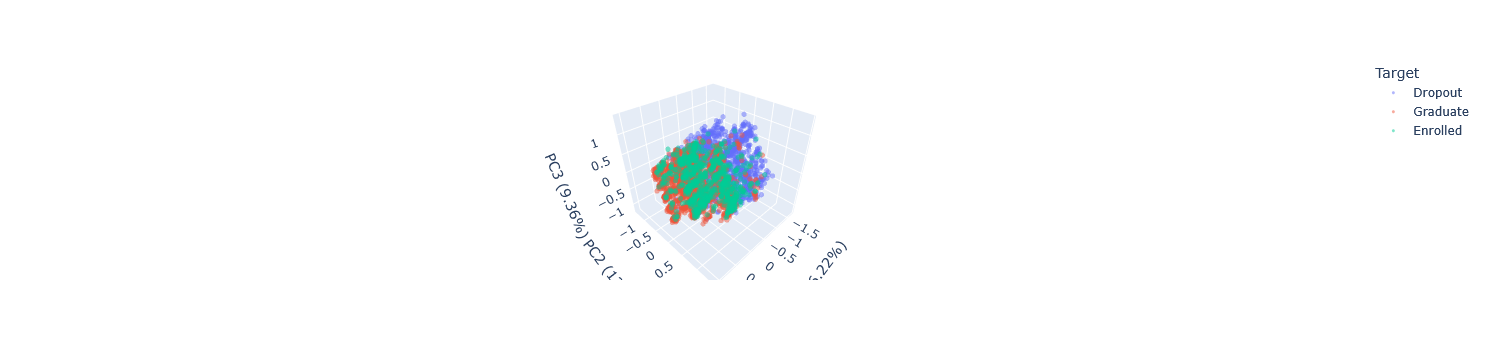

In [5]:
# Aplicação Método PCA para 3 componentes
pca = PCA(n_components = 3)
principalComponents = pca.fit_transform(scaled_students_df)

pca_df = pd.DataFrame(
    data = principalComponents,
    columns = ['principal component 1', 'principal component 2', 'principal component 3'])

graphic_pca_df = pd.concat([pca_df, y.reset_index(drop = True)], axis = 1)

fig = px.scatter_3d(
    graphic_pca_df,
    x = 'principal component 1',
    y = 'principal component 2',
    z = 'principal component 3',
    color = y.name,
    opacity = 0.5,)
fig.update_traces(marker = dict(size = 3))
fig.update_layout(
    scene = dict(
        xaxis_title = f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)',
        yaxis_title = f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)',
        zaxis_title = f'PC3 ({pca.explained_variance_ratio_[2]*100:.2f}%)' ))
fig.show()
#fig.write_html("PCA_students_df.html")

---

<p style="text-align: justify; font-size: 1.15em;">
O bloco de código acima implementa o algoritmo PCA por meio da classe <code>PCA(n_components=3)</code>. O <strong>número de componentes foi deliberadamente limitado a três</strong> por ser o limite máximo para a visualização geométrica tridimensional; contudo, o espaço amostral permitiria a extração de até 35 componentes, dado que o limite teórico é definido pelo número total de atributos da base de dados original (desconsiderando-se a variável alvo). O gráfico 3D gerado foi salvo em um arquivo do tipo <code>.html</code> para melhor visualização por meio da função <code>fig.write.html()</code>, os rótulos da coluna <code>Target</code> foram utilizados exclusivamente para fins de codificação de cor, permitindo inspecionar visualmente o grau de separabilidade das classes. Todavia, a análise quantitativa revela uma <strong>baixa variância explicada acumulada para essas três componentes</strong>, representando menos de 50% da informação contida na base de dados original. Esse comportamento evidencia que uma redução drástica para apenas três dimensões não se prova suficientemente eficiente para o conjunto de dados selecionado, uma vez que acarreta uma perda severa de informação. Uma investigação detalhada acerca do número ideal de componentes necessárias para atingir um limiar aceitável de variância explicada é apresentada abaixo.
</p>

---

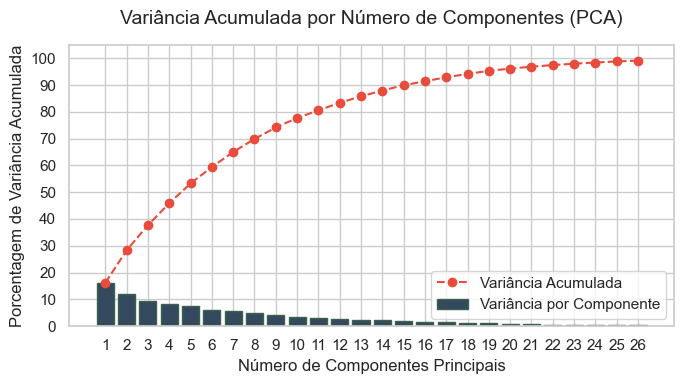

In [28]:
# PCA para o máximo de compoenentes (limite de colunas do dataset)
pca_full = PCA()
pca_full.fit(scaled_students_df)

# cálculo das variâncias em porcentagem
variancia_individual_cortada = (pca_full.explained_variance_ratio_ * 100)[:n_componentes_limite]
variancia_acumulada_cortada = (np.cumsum(pca_full.explained_variance_ratio_) * 100)[:n_componentes_li

# gráfico com as variâncias acumuladas para descobrir melhor parâmetro de componentes n do PCA
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 4))

# plotagem do gráfico de barras para cada variância individual (usando os dados cortados)
plt.bar(
    range(1, n_componentes_limite + 1),
    variancia_individual_cortada,
    color='#34495E',
    edgecolor='#3a634e',
    label='Variância por Componente'
)

# plotagem da linha para variância acumulada do PCA (usando os dados cortados)
plt.plot(
    range(1, n_componentes_limite + 1), 
    variancia_acumulada_cortada, 
    marker='o', 
    linestyle='--', 
    color='#E74C3C',
    label='Variância Acumulada'
)
plt.title('Variância Acumulada por Número de Componentes (PCA)', fontsize=14, pad=15)
plt.xlabel('Número de Componentes Principais', fontsize=12)
plt.ylabel('Porcentagem de Variância Acumulada', fontsize=12)
plt.xticks(range(1, n_componentes_limite + 1))
plt.yticks(np.arange(0, 101, step=10))
plt.ylim(0, 105)
plt.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()

---

<p style="text-align: justify; font-size: 1.15em;">
A última célula de código desta etapa do projeto calcula a variância explicada individual e acumulada, por meio das variáveis <code>variancia_individual_cortada</code> e <code>variancia_acumulada_cortada</code> para cada uma das componentes do PCA considerando o limite máximo de variância de 100%. O gráfico gerado evidencia a variância explicada por componente por meio de barras e o comportamento da variância acumulada em direção ao limite referencial de 100%. Contudo, fica evidente que para reter uma variância explicada dentro de um limiar aceitável na literatura de mineração de dados, geralmente situado <strong>entre 80% a 90%</strong>, o número de componentes necessárias não reduz de forma satisfatória, sendo necessárias <strong>11 a 15 componentes</strong>. Para alcançar esse patamar de informação, <strong>faz-se necessária a preservação de uma quantidade elevada de dimensões</strong>. Diante deste cenário, a aplicação da redução de dimensionalidade mostra-se ineficiente para este conjunto de dados específico, justificando a decisão metodológica de utilizar a base de dados completa para as etapas subsequentes do projeto.
</p>

---